In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())  # important - check for missing values

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.Cabin.nunique()

147

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df = df.dropna(subset=['Embarked'])

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [8]:
df = df.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    str    
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 62.5 KB


In [10]:
print(df['SibSp'].value_counts())

SibSp
0    606
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


In [11]:
df = pd.get_dummies(df, columns=['Embarked'], dtype=int)

In [12]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,male,22.0,1,0,7.2500,0,0,1
1,1,1,female,38.0,1,0,71.2833,1,0,0
2,1,3,female,26.0,0,0,7.9250,0,0,1
3,1,1,female,35.0,1,0,53.1000,0,0,1
4,0,3,male,35.0,0,0,8.0500,0,0,1


In [13]:
df.dtypes

Survived        int64
Pclass          int64
Sex               str
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_C      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object

In [14]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})  # binary encode

In [15]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [16]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [17]:
x = df.drop('Survived', axis=1).values  # all columns except Survived, as a numpy array
y = df['Survived'].values                # just the Survived column, as a numpy array

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42  # 80% train, 20% test, fixed seed for reproducibility
)

In [19]:
from sklearn.utils import shuffle

x_train, y_train = shuffle(x_train, y_train, random_state=42)  # shuffle before k-fold

In [20]:
x_train.shape

(711, 9)

In [21]:
print(df.dtypes)

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_C      int64
Embarked_Q      int64
Embarked_S      int64
dtype: object


In [22]:
x_train.dtype

dtype('float64')

In [23]:
print(pd.DataFrame(x_train).dtypes)

0    float64
1    float64
2    float64
3    float64
4    float64
5    float64
6    float64
7    float64
8    float64
dtype: object


In [24]:
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)
x_train = (x_train - mean) / std
x_test = (x_test- mean) / std

In [25]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(36, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(36, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [26]:
import numpy as np
from keras.callbacks import EarlyStopping, ModelCheckpoint

k = 5
num_val_samples = len(x_train) // k
num_epochs = 100
all_accu_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    checkpoint = ModelCheckpoint(
        "titanic_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
    history = model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
        validation_data=(fold_x_val, fold_y_val),
        callbacks=[early_stopping, checkpoint]
    )
    accu_history = history.history["accuracy"]
    all_accu_histories.append(accu_history)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4
Processing fold #5


In [27]:
min_epochs = min(len(x) for x in all_accu_histories)  # find shortest fold

average_accu_history = [
    np.mean([x[i] for x in all_accu_histories]) for i in range(min_epochs)  # only go up to min length
]

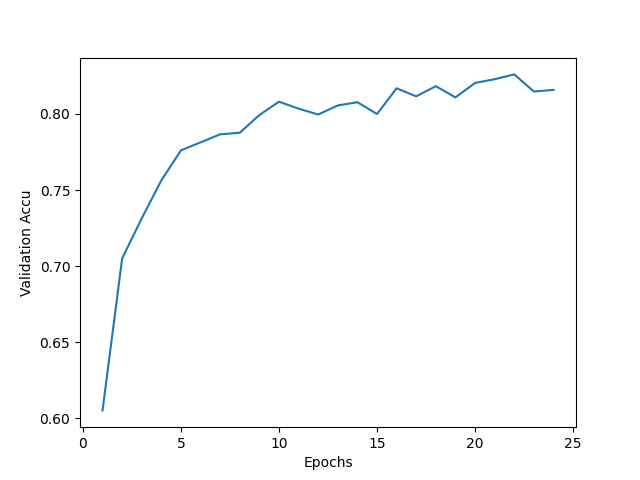

In [28]:
%matplotlib widget
import matplotlib.pyplot as plt
plt.clf()

epochs = range(1, len(average_accu_history) + 1)
plt.plot(epochs, average_accu_history)
plt.xlabel("Epochs")
plt.ylabel("Validation Accu")
plt.show()

In [29]:
all_accu_histories

[[0.5922671556472778,
  0.6994727849960327,
  0.6994727849960327,
  0.7416520118713379,
  0.7451669573783875,
  0.76625657081604,
  0.790861189365387,
  0.7873462438583374,
  0.7750439643859863,
  0.7873462438583374,
  0.8119508028030396,
  0.7926186323165894,
  0.7978910207748413,
  0.8049209117889404,
  0.7715290188789368,
  0.8242530822753906,
  0.8014059662818909,
  0.8242530822753906,
  0.8154657483100891,
  0.8224955797195435,
  0.8049209117889404,
  0.8189806938171387,
  0.803163468837738,
  0.8224955797195435],
 [0.57469242811203,
  0.6959578394889832,
  0.753954291343689,
  0.7697715163230896,
  0.7873462438583374,
  0.7820737957954407,
  0.790861189365387,
  0.7961335778236389,
  0.8119508028030396,
  0.8242530822753906,
  0.8101933002471924,
  0.8207381367683411,
  0.7996485233306885,
  0.8119508028030396,
  0.8014059662818909,
  0.8172231912612915,
  0.8137082457542419,
  0.80843585729599,
  0.8189806938171387,
  0.80843585729599,
  0.8347979187965393,
  0.8453426957130432,

In [30]:
len(history.history["accuracy"])


47

In [31]:
early_stopping.stopped_epoch

46

In [ ]:
model = get_model()
model.fit(x_train, y_train, epochs=35, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8258 - loss: 0.4907


In [33]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8258 - loss: 0.4907
Test loss: 0.4907
Test accuracy: 0.8258


In [34]:
import os
print(os.getcwd())


c:\Users\chris\repositories\deep-learning-with-python-notebooks


In [35]:
model.save("titanic.keras")

In [36]:
model = keras.models.load_model("titanic_best.keras")
#model.get_config()

In [37]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (16, 36)               │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (16, 36)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (16, 36)               │         1,332 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (16, 36)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (16, 1)                │            37 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,189 (20.27 KB)

 Trainable params: 1,729 (6.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,460 (13.52 KB)